In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os
import warnings
warnings.filterwarnings("ignore")
import xesmf as xe
from scipy import stats

# Add analysis path
analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)
import myfunctions as mf

# =========================
# Physical constants
# =========================
Cp = 1005.0    # J kg-1 K-1
Lv = 2.5e6     # J kg-1
trop_lat=90

# =========================
# Base CEDA paths
# =========================
CEDA_BASE = Path("/badc/cmip6/data/CMIP6")

# =========================
# Model Names
# =========================
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}

# =========================
# Experiment registry (in desired plot order)
# =========================
EXPERIMENTS_ORDER = ["HIST", "SSP585", "SSP245", "G6sulfur"]

EXPERIMENTS = {
    "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# =========================
# Utility functions
# =========================
def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return ("2021-01-01", "2100-12")
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")

def get_var_name(vname, model_name):
    """Handle model-specific variable name exceptions."""
    return vname

def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    ds_in = da.to_dataset(name='data')
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da)

# =========================
# BLOCK 1: COMPUTE SCATTER DATA
# =========================
print("="*80)
print("BLOCK 1: Loading data and computing scatter arrays")
print("="*80)

scatter_data = {}

for model_name, model_meta in MODELS.items():
    print(f"\n{'='*60}")
    print(f"Processing model: {model_name}")
    print(f"{'='*60}")
    
    scatter_data[model_name] = {}

    for exp in EXPERIMENTS_ORDER:
        meta = EXPERIMENTS[exp]
        print(f"\n--- Experiment: {exp} ---")
        
        # Special-case ensemble override for CESM2-WACCM
        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        def make_base(vname):
            return (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / vname
                / model_meta["grid"]
                / "latest"
            )

        base_tas = make_base("tas")
        base_huss = make_base("huss")
        base_pr = make_base("pr")

        try:
            # Load datasets based on model-specific functions
            if model_name == "CESM2-WACCM":
                if meta["scenario"] == "G6sulfur":
                    ds_tas = mf.open_files_CESM_G6sulfur(base_tas)
                    ds_huss = mf.open_files_CESM_G6sulfur(base_huss)
                    ds_pr = mf.open_files_CESM_G6sulfur(base_pr)
                elif meta["scenario"] == "ssp585":
                    ds_tas = mf.open_files_CESM_ssp585(base_tas)
                    ds_huss = mf.open_files_CESM_ssp585(base_huss)
                    ds_pr = mf.open_files_CESM_ssp585(base_pr)
                else:
                    ds_tas = mf.open_files(str(base_tas))
                    ds_huss = mf.open_files(str(base_huss))
                    ds_pr = mf.open_files(str(base_pr))
            elif model_name == "IPSL-CM6A-LR":
                if meta["scenario"] == "ssp585":
                    ds_tas = mf.open_files_IPSL_ssp585(base_tas)
                    ds_huss = mf.open_files_IPSL_ssp585(base_huss)
                    ds_pr = mf.open_files_IPSL_ssp585(base_pr)
                else:
                    ds_tas = mf.open_files(str(base_tas))
                    ds_huss = mf.open_files(str(base_huss))
                    ds_pr = mf.open_files(str(base_pr))
            else:
                ds_tas = mf.open_files(str(base_tas))
                ds_huss = mf.open_files(str(base_huss))
                ds_pr = mf.open_files(str(base_pr))

            # Read variables
            da_tas = mf.read_var(ds_tas, "tas")
            da_huss = mf.read_var(ds_huss, "huss")
            da_pr = mf.read_var(ds_pr, "pr")
            
            # Drop unnecessary coordinates
            da_huss = da_huss.drop_vars(["plev", "height"], errors="ignore")
            da_tas = da_tas.drop_vars(["plev", "height"], errors="ignore")
            da_pr = da_pr.drop_vars(["plev", "height"], errors="ignore")

            # Time slice
            t_start, t_end = _time_slice(exp)
            da_tas_sliced = da_tas.sel(time=slice(t_start, t_end), lat=slice(-trop_lat,trop_lat))
            da_huss_sliced = da_huss.sel(time=slice(t_start, t_end), lat=slice(-trop_lat,trop_lat))
            da_pr_sliced = da_pr.sel(time=slice(t_start, t_end), lat=slice(-trop_lat,trop_lat))
            
            print(f"  Sliced to {da_tas_sliced.sizes['time']} months")

            # Compute MSEsfc in kJ/kg
            da_mse = (Lv * da_huss_sliced) / 1000.0
            
            # Convert pr to mm/day
            da_pr_mmday = da_pr_sliced * 86400

            # Regrid to common grid
            print("  Regridding...")
            da_mse_regrid = regrid_to_common(da_mse)
            da_pr_regrid = regrid_to_common(da_pr_mmday)
            
            # Flatten and remove NaNs
            mse_flat = da_mse_regrid.values.flatten()
            pr_flat = da_pr_regrid.values.flatten()
            
            valid_mask = ~(np.isnan(mse_flat) | np.isnan(pr_flat))
            mse_valid = mse_flat[valid_mask]
            pr_valid = pr_flat[valid_mask]
            
            # Store
            scatter_data[model_name][exp] = {
                'mse': mse_valid,
                'pr': pr_valid
            }
            
            print(f"  ✓ Valid points: {len(mse_valid):,}")
            print(f"    MSE: {mse_valid.min():.1f} - {mse_valid.max():.1f} kJ/kg")
            print(f"    PR:  {pr_valid.min():.2f} - {pr_valid.max():.2f} mm/day")
            
        except Exception as e:
            print(f"  ✗ Error loading {exp}: {e}")
            scatter_data[model_name][exp] = None

print("\n" + "="*80)
print("BLOCK 1 COMPLETE: All data loaded and processed")
print("="*80)

# # =========================
# # BLOCK 2: CREATE SCATTER PLOTS
# # =========================
# print("\n" + "="*80)
# print("BLOCK 2: Creating scatter plots")
# print("="*80)

# # Define colors for each model
# model_colors = {
#     "UKESM1-0-LL": "#1f77b4",
#     "CNRM-ESM2-1": "#ff7f0e",
#     "MPI-ESM1-2-LR": "#2ca02c",
#     "CESM2-WACCM": "#d62728",
#     "IPSL-CM6A-LR": "#9467bd"
# }

# # Set axis limits as specified
# mse_min, mse_max = 200, 400  # kJ/kg
# pr_min, pr_max = 0, 100  # mm/day (as per your instruction)

# # Create figure: 6 rows (5 models + 1 multi-model) x 4 columns (experiments)
# n_models = len(MODELS)
# n_exp = len(EXPERIMENTS_ORDER)
# fig, axes = plt.subplots(n_models + 1, n_exp, figsize=(16, 20))
# fig.suptitle('MSE-Precipitation Relationship Across Climate Models and Scenarios', 
#              fontsize=14, fontweight='bold', y=0.995)

# # Rows 0-4: One row per model, 4 columns for experiments
# for row_idx, model_name in enumerate(MODELS.keys()):
#     for col_idx, exp in enumerate(EXPERIMENTS_ORDER):
#         ax = axes[row_idx, col_idx]
        
#         data = scatter_data[model_name].get(exp)
        
#         if data is not None:
#             mse = data['mse']
#             pr = data['pr']
            
#             # Subsample for plotting (to avoid overplotting)
#             n_sample = min(5000, len(mse))
#             indices = np.random.choice(len(mse), n_sample, replace=False)
            
#             # Scatter plot
#             ax.scatter(mse[indices], pr[indices], 
#                       alpha=0.2, s=2, c=model_colors[model_name],
#                       edgecolors='none', rasterized=True)
            
#             # Linear regression
#             slope, intercept, r_value, p_value, std_err = stats.linregress(mse, pr)
#             mse_line = np.array([mse_min, mse_max])
#             pr_line = slope * mse_line + intercept
            
#             ax.plot(mse_line, pr_line, 'r-', linewidth=2.5, 
#                    label=f'slope={slope:.3f}')
            
#             # Formatting
#             ax.set_xlim(mse_min, mse_max)
#             ax.set_ylim(pr_min, pr_max)
#             ax.grid(True, alpha=0.3, linewidth=0.5)
#             ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
            
#             # Row labels (model names on left)
#             if col_idx == 0:
#                 ax.set_ylabel(f'{model_name}\n\nPR (mm/day)', fontsize=10, fontweight='bold')
            
#             # Bottom row x-labels
#             if row_idx == n_models - 1:
#                 ax.set_xlabel('MSE (kJ/kg)', fontsize=10)
            
#             # Column titles (experiment names on top)
#             if row_idx == 0:
#                 ax.set_title(exp, fontsize=12, fontweight='bold', pad=10)
                
#         else:
#             ax.text(0.5, 0.5, 'Data not available', 
#                    ha='center', va='center', transform=ax.transAxes,
#                    fontsize=10, style='italic', color='gray')
#             ax.set_xlim(mse_min, mse_max)
#             ax.set_ylim(pr_min, pr_max)
#             ax.grid(True, alpha=0.2)
            
#             if col_idx == 0:
#                 ax.set_ylabel(f'{model_name}\n\nPR (mm/day)', fontsize=10, fontweight='bold')

# # Row 5: Multi-model combined (one column per experiment)
# for col_idx, exp in enumerate(EXPERIMENTS_ORDER):
#     ax = axes[n_models, col_idx]
    
#     # Combine all models for this experiment
#     all_mse_list = []
#     all_pr_list = []
    
#     for model_name in MODELS.keys():
#         data = scatter_data[model_name].get(exp)
#         if data is not None:
#             # Sample from each model to balance representation
#             n_sub = min(1000, len(data['mse']))
#             idx = np.random.choice(len(data['mse']), n_sub, replace=False)
            
#             ax.scatter(data['mse'][idx], data['pr'][idx], 
#                       alpha=0.15, s=3, c=model_colors[model_name],
#                       label=model_name, edgecolors='none', rasterized=True)
            
#             all_mse_list.extend(data['mse'])
#             all_pr_list.extend(data['pr'])
    
#     if all_mse_list:
#         all_mse = np.array(all_mse_list)
#         all_pr = np.array(all_pr_list)
        
#         # Multi-model slope
#         slope, intercept, r_value, p_value, std_err = stats.linregress(all_mse, all_pr)
#         mse_line = np.array([mse_min, mse_max])
#         pr_line = slope * mse_line + intercept
        
#         ax.plot(mse_line, pr_line, 'k-', linewidth=3.5, 
#                label=f'Multi-model: slope={slope:.3f}', zorder=10)
        
#         # Formatting
#         ax.set_xlim(mse_min, mse_max)
#         ax.set_ylim(pr_min, pr_max)
#         ax.grid(True, alpha=0.3, linewidth=0.5)
#         ax.legend(loc='upper left', fontsize=7, framealpha=0.9, ncol=2)
#         ax.set_xlabel('MSE (kJ/kg)', fontsize=10, fontweight='bold')
        
#         if col_idx == 0:
#             ax.set_ylabel('All Models\n\nPR (mm/day)', fontsize=10, fontweight='bold')

# plt.tight_layout()

# # # Save
# # output_path = '/home/claude/mse_pr_scatter_analysis.png'
# # plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
# # print(f"\n✓ Figure saved: {output_path}")

# # # Copy to outputs for user access
# # import shutil
# # output_final = '/mnt/user-data/outputs/mse_pr_scatter_analysis.png'
# # shutil.copy(output_path, output_final)
# # print(f"✓ Figure copied to: {output_final}")

# # =========================
# # SUMMARY TABLE
# # =========================
# print("\n" + "="*80)
# print("SUMMARY: MSE-PR Regression Slopes")
# print("="*80)
# print(f"{'Model':<20} {'HIST':>12} {'SSP585':>12} {'SSP245':>12} {'G6sulfur':>12}")
# print("-"*80)

# for model_name in MODELS.keys():
#     row = f"{model_name:<20}"
#     for exp in EXPERIMENTS_ORDER:
#         data = scatter_data[model_name].get(exp)
#         if data is not None:
#             slope = stats.linregress(data['mse'], data['pr'])[0]
#             row += f" {slope:>12.4f}"
#         else:
#             row += f" {'N/A':>12}"
#     print(row)

# print("-"*80)
# print("\nMulti-model slopes:")
# for exp in EXPERIMENTS_ORDER:
#     all_mse = []
#     all_pr = []
#     for model_name in MODELS.keys():
#         data = scatter_data[model_name].get(exp)
#         if data is not None:
#             all_mse.extend(data['mse'])
#             all_pr.extend(data['pr'])
    
#     if all_mse:
#         slope = stats.linregress(all_mse, all_pr)[0]
#         print(f"  {exp:<12}: {slope:.4f} mm·day⁻¹·(kJ/kg)⁻¹")

# print("\n" + "="*80)
# print("Analysis complete!")
# print("="*80)

BLOCK 1: Loading data and computing scatter arrays

Processing model: UKESM1-0-LL

--- Experiment: HIST ---
  Sliced to 960 months
  Regridding...
  ✓ Valid points: 5,667,840
    MSE: 0.0 - 59.5 kJ/kg
    PR:  0.00 - 82.10 mm/day

--- Experiment: SSP585 ---
  Sliced to 960 months
  Regridding...
  ✓ Valid points: 5,667,840
    MSE: 0.0 - 78.3 kJ/kg
    PR:  0.00 - 271.64 mm/day

--- Experiment: SSP245 ---
  Sliced to 960 months
  Regridding...
  ✓ Valid points: 5,667,840
    MSE: 0.0 - 69.3 kJ/kg
    PR:  0.00 - 84.83 mm/day

--- Experiment: G6sulfur ---
  Sliced to 960 months
  Regridding...
  ✓ Valid points: 5,667,840
    MSE: 0.0 - 68.0 kJ/kg
    PR:  0.00 - 155.09 mm/day

Processing model: CNRM-ESM2-1

--- Experiment: HIST ---
  Sliced to 960 months
  Regridding...
  ✓ Valid points: 5,667,840
    MSE: 0.5 - 54.1 kJ/kg
    PR:  0.00 - 86.83 mm/day

--- Experiment: SSP585 ---
  Sliced to 960 months
  Regridding...
  ✓ Valid points: 5,667,840
    MSE: 0.7 - 69.5 kJ/kg
    PR:  0.00 - 

In [2]:
# # =========================
# # BLOCK 2: CREATE SCATTER PLOTS
# # =========================
# print("\n" + "="*80)
# print("BLOCK 2: Creating scatter plots")
# print("="*80)

# # Define colors for each model
# model_colors = {
#     "UKESM1-0-LL": "#1f77b4",
#     "CNRM-ESM2-1": "#ff7f0e",
#     "MPI-ESM1-2-LR": "#2ca02c",
#     "CESM2-WACCM": "#d62728",
#     "IPSL-CM6A-LR": "#9467bd"
# }

# # Set axis limits as specified
# mse_min, mse_max = 225, 375  # kJ/kg
# pr_min, pr_max = 0, 40  # mm/day (as per your instruction)

# # Create figure: 6 rows (5 models + 1 multi-model) x 4 columns (experiments)
# n_models = len(MODELS)
# n_exp = len(EXPERIMENTS_ORDER)
# fig, axes = plt.subplots(n_models + 1, n_exp, figsize=(16, 20))
# fig.suptitle('MSE-Precipitation Relationship Across Climate Models and Scenarios', 
#              fontsize=14, fontweight='bold', y=0.995)

# # Rows 0-4: One row per model, 4 columns for experiments
# for row_idx, model_name in enumerate(MODELS.keys()):
#     for col_idx, exp in enumerate(EXPERIMENTS_ORDER):
#         ax = axes[row_idx, col_idx]
        
#         data = scatter_data[model_name].get(exp)
        
#         if data is not None:
#             mse = data['mse']
#             pr = data['pr']
            
#             # Subsample for plotting (to avoid overplotting)
#             n_sample = min(5000, len(mse))
#             indices = np.random.choice(len(mse), n_sample, replace=False)
            
#             # Scatter plot
#             ax.scatter(mse[indices], pr[indices], 
#                       alpha=0.2, s=2, c=model_colors[model_name],
#                       edgecolors='none', rasterized=True)
            
#             # Linear regression
#             slope, intercept, r_value, p_value, std_err = stats.linregress(mse, pr)
#             mse_line = np.array([mse_min, mse_max])
#             pr_line = slope * mse_line + intercept
            
#             ax.plot(mse_line, pr_line, 'r-', linewidth=2.5, 
#                    label=f'slope={slope:.3f}')
            
#             # Formatting
#             ax.set_xlim(mse_min, mse_max)
#             ax.set_ylim(pr_min, pr_max)
#             ax.grid(True, alpha=0.3, linewidth=0.5)
#             ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
            
#             # Row labels (model names on left)
#             if col_idx == 0:
#                 ax.set_ylabel(f'{model_name}\n\nPR (mm/day)', fontsize=10, fontweight='bold')
            
#             # Bottom row x-labels
#             if row_idx == n_models - 1:
#                 ax.set_xlabel('MSE (kJ/kg)', fontsize=10)
            
#             # Column titles (experiment names on top)
#             if row_idx == 0:
#                 ax.set_title(exp, fontsize=12, fontweight='bold', pad=10)
                
#         else:
#             ax.text(0.5, 0.5, 'Data not available', 
#                    ha='center', va='center', transform=ax.transAxes,
#                    fontsize=10, style='italic', color='gray')
#             ax.set_xlim(mse_min, mse_max)
#             ax.set_ylim(pr_min, pr_max)
#             ax.grid(True, alpha=0.2)
            
#             if col_idx == 0:
#                 ax.set_ylabel(f'{model_name}\n\nPR (mm/day)', fontsize=10, fontweight='bold')

# # Row 5: Multi-model combined (one column per experiment)
# for col_idx, exp in enumerate(EXPERIMENTS_ORDER):
#     ax = axes[n_models, col_idx]
    
#     # Combine all models for this experiment
#     all_mse_list = []
#     all_pr_list = []
    
#     for model_name in MODELS.keys():
#         data = scatter_data[model_name].get(exp)
#         if data is not None:
#             # Sample from each model to balance representation
#             n_sub = min(1000, len(data['mse']))
#             idx = np.random.choice(len(data['mse']), n_sub, replace=False)
            
#             ax.scatter(data['mse'][idx], data['pr'][idx], 
#                       alpha=0.15, s=3, c=model_colors[model_name],
#                       label=model_name, edgecolors='none', rasterized=True)
            
#             all_mse_list.extend(data['mse'])
#             all_pr_list.extend(data['pr'])
    
#     if all_mse_list:
#         all_mse = np.array(all_mse_list)
#         all_pr = np.array(all_pr_list)
        
#         # Multi-model slope
#         slope, intercept, r_value, p_value, std_err = stats.linregress(all_mse, all_pr)
#         mse_line = np.array([mse_min, mse_max])
#         pr_line = slope * mse_line + intercept
        
#         ax.plot(mse_line, pr_line, 'k-', linewidth=3.5, 
#                label=f'Multi-model: slope={slope:.3f}', zorder=10)
        
#         # Formatting
#         ax.set_xlim(mse_min, mse_max)
#         ax.set_ylim(pr_min, pr_max)
#         ax.grid(True, alpha=0.3, linewidth=0.5)
#         ax.legend(loc='upper left', fontsize=7, framealpha=0.9, ncol=2)
#         ax.set_xlabel('MSE (kJ/kg)', fontsize=10, fontweight='bold')
        
#         if col_idx == 0:
#             ax.set_ylabel('All Models\n\nPR (mm/day)', fontsize=10, fontweight='bold')

# plt.tight_layout()

# # # Save
# # output_path = '/home/claude/mse_pr_scatter_analysis.png'
# # plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
# # print(f"\n✓ Figure saved: {output_path}")

# # # Copy to outputs for user access
# # import shutil
# # output_final = '/mnt/user-data/outputs/mse_pr_scatter_analysis.png'
# # shutil.copy(output_path, output_final)
# # print(f"✓ Figure copied to: {output_final}")

# # =========================
# # SUMMARY TABLE
# # =========================
# print("\n" + "="*80)
# print("SUMMARY: MSE-PR Regression Slopes")
# print("="*80)
# print(f"{'Model':<20} {'HIST':>12} {'SSP585':>12} {'SSP245':>12} {'G6sulfur':>12}")
# print("-"*80)

# for model_name in MODELS.keys():
#     row = f"{model_name:<20}"
#     for exp in EXPERIMENTS_ORDER:
#         data = scatter_data[model_name].get(exp)
#         if data is not None:
#             slope = stats.linregress(data['mse'], data['pr'])[0]
#             row += f" {slope:>12.4f}"
#         else:
#             row += f" {'N/A':>12}"
#     print(row)

# print("-"*80)
# print("\nMulti-model slopes:")
# for exp in EXPERIMENTS_ORDER:
#     all_mse = []
#     all_pr = []
#     for model_name in MODELS.keys():
#         data = scatter_data[model_name].get(exp)
#         if data is not None:
#             all_mse.extend(data['mse'])
#             all_pr.extend(data['pr'])
    
#     if all_mse:
#         slope = stats.linregress(all_mse, all_pr)[0]
#         print(f"  {exp:<12}: {slope:.4f} mm·day⁻¹·(kJ/kg)⁻¹")

# print("\n" + "="*80)
# print("Analysis complete!")
# print("="*80)


BLOCK 2: Computing binned PR statistics for each MSE bin
  UKESM1-0-LL - HIST: 39 bins, 5,667,840 total points
  UKESM1-0-LL - SSP585: 39 bins, 5,667,840 total points
  UKESM1-0-LL - SSP245: 39 bins, 5,667,840 total points
  UKESM1-0-LL - G6sulfur: 39 bins, 5,667,840 total points
  CNRM-ESM2-1 - HIST: 39 bins, 5,667,840 total points
  CNRM-ESM2-1 - SSP585: 39 bins, 5,667,840 total points
  CNRM-ESM2-1 - SSP245: 39 bins, 5,667,840 total points
  CNRM-ESM2-1 - G6sulfur: 39 bins, 5,667,840 total points
  MPI-ESM1-2-LR - HIST: 39 bins, 5,667,840 total points
  MPI-ESM1-2-LR - SSP585: 39 bins, 5,667,840 total points
  MPI-ESM1-2-LR - SSP245: 39 bins, 5,667,840 total points
  MPI-ESM1-2-LR - G6sulfur: 39 bins, 5,596,992 total points
  CESM2-WACCM - HIST: 39 bins, 5,667,840 total points
  CESM2-WACCM - SSP585: 39 bins, 5,667,840 total points
  CESM2-WACCM - SSP245: 39 bins, 5,667,840 total points
  CESM2-WACCM - G6sulfur: 39 bins, 5,667,840 total points
  IPSL-CM6A-LR - HIST: 39 bins, 5,667,

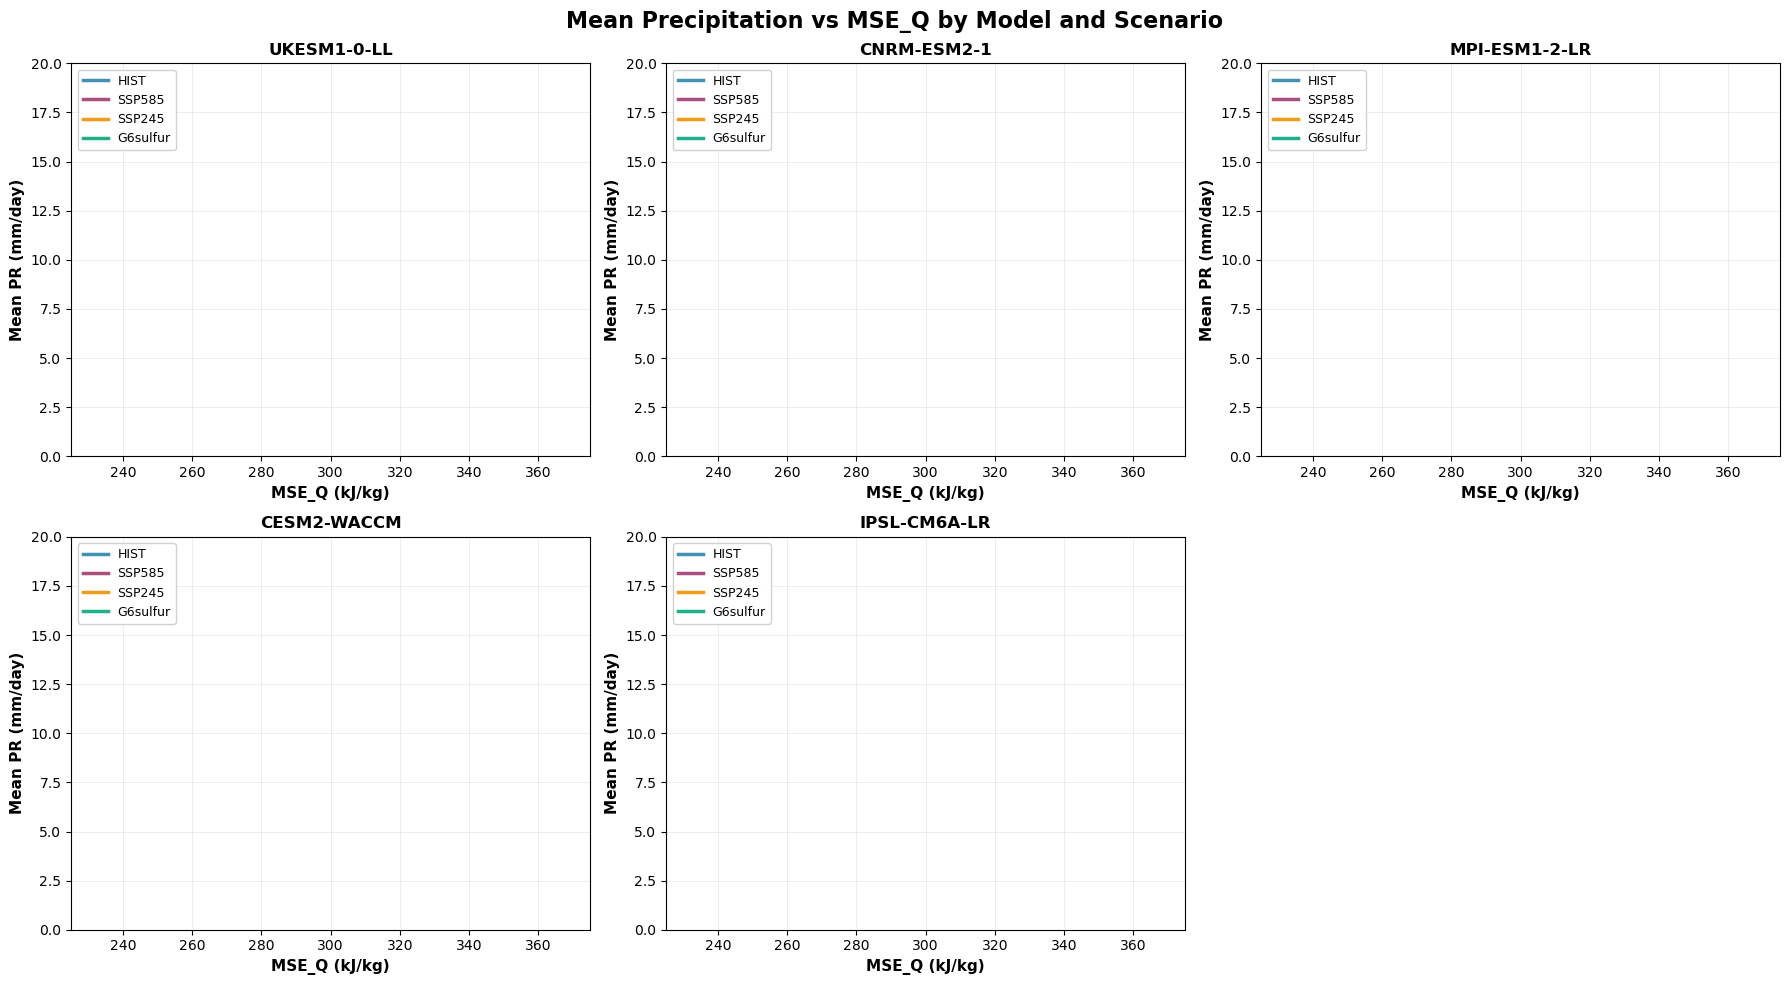

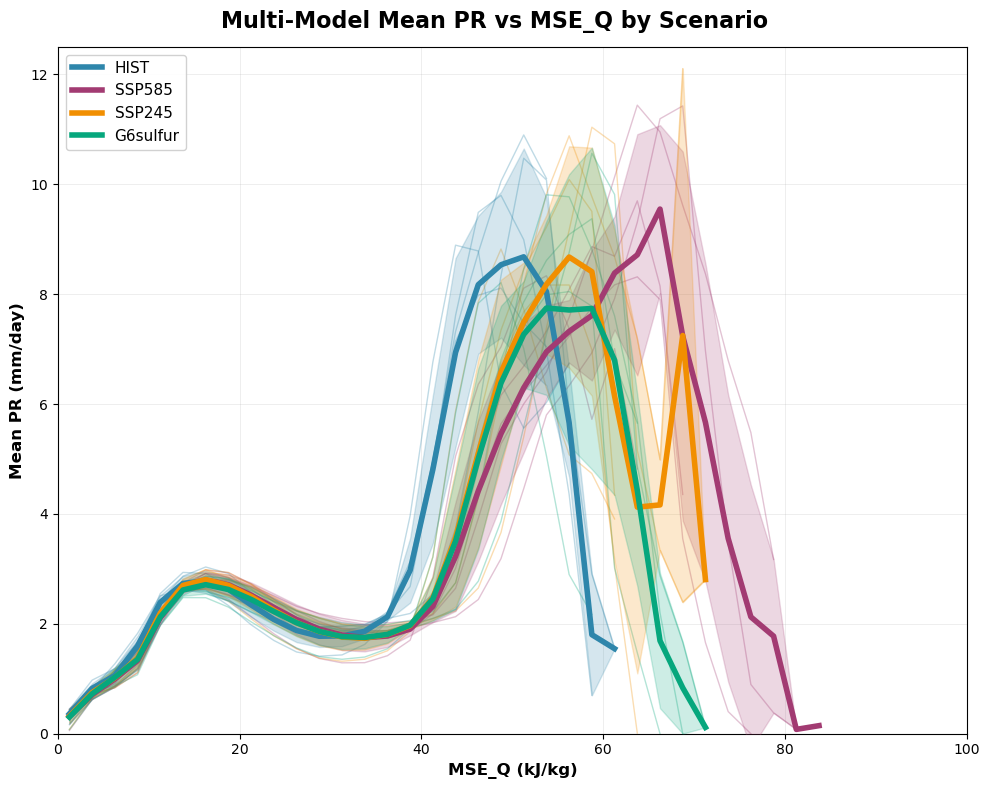

In [6]:
# =========================
# BLOCK 2: COMPUTE BINNED STATISTICS
# =========================
print("\n" + "="*80)
print("BLOCK 2: Computing binned PR statistics for each MSE bin")
print("="*80)
 
# Define MSE bins
mse_bins = np.arange(0, 100, 2.5)  # 2.5 kJ/kg bins from 225 to 375
mse_centers = (mse_bins[:-1] + mse_bins[1:]) / 2
 
# Store binned data
binned_stats = {}
 
for model_name in MODELS.keys():
    binned_stats[model_name] = {}
    
    for exp in EXPERIMENTS_ORDER:
        data = scatter_data[model_name].get(exp)
        
        if data is not None:
            mse = data['mse']
            pr = data['pr']
            
            # Compute mean PR in each MSE bin
            pr_binned_mean = []
            pr_binned_std = []
            counts = []
            
            for i in range(len(mse_bins) - 1):
                mask = (mse >= mse_bins[i]) & (mse < mse_bins[i+1])
                pr_in_bin = pr[mask]
                
                if len(pr_in_bin) > 0:
                    pr_binned_mean.append(np.mean(pr_in_bin))
                    pr_binned_std.append(np.std(pr_in_bin))
                    counts.append(len(pr_in_bin))
                else:
                    pr_binned_mean.append(np.nan)
                    pr_binned_std.append(np.nan)
                    counts.append(0)
            
            binned_stats[model_name][exp] = {
                'mse_centers': mse_centers,
                'pr_mean': np.array(pr_binned_mean),
                'pr_std': np.array(pr_binned_std),
                'counts': np.array(counts)
            }
            
            print(f"  {model_name} - {exp}: {len(pr_binned_mean)} bins, "
                  f"{np.sum(counts):,} total points")
 
print("\n" + "="*80)
print("BLOCK 2 COMPLETE: Binned statistics computed")
print("="*80)
 
# =========================
# BLOCK 3: PLOT 1 - One panel per model with 4 experiment lines
# =========================
print("\n" + "="*80)
print("BLOCK 3: Creating Figure 1 - Mean PR distributions per model")
print("="*80)
 
# Define colors for experiments
exp_colors = {
    "HIST": "#2E86AB",      # Blue
    "SSP585": "#A23B72",    # Purple-red
    "SSP245": "#F18F01",    # Orange
    "G6sulfur": "#06A77D"   # Green
}
 
# Create figure with one panel per model
fig1, axes1 = plt.subplots(2, 3, figsize=(18, 10))
axes1 = axes1.flatten()
fig1.suptitle('Mean Precipitation vs MSE_Q by Model and Scenario', 
              fontsize=16, fontweight='bold')
 
for idx, model_name in enumerate(MODELS.keys()):
    ax = axes1[idx]
    
    # Plot each experiment as a line
    for exp in EXPERIMENTS_ORDER:
        stats = binned_stats[model_name].get(exp)
        
        if stats is not None:
            # Plot mean PR
            ax.plot(stats['mse_centers'], stats['pr_mean'], 
                   color=exp_colors[exp], linewidth=2.5, 
                   label=exp, alpha=0.9)
            
            # Optional: Add shaded region for ±1 std dev
            ax.fill_between(stats['mse_centers'], 
                           stats['pr_mean'] - stats['pr_std'],
                           stats['pr_mean'] + stats['pr_std'],
                           color=exp_colors[exp], alpha=0.15)
    
    # Formatting
    ax.set_xlim(225, 375)
    ax.set_ylim(0, 20)
    ax.set_xlabel('MSE_Q (kJ/kg)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean PR (mm/day)', fontsize=11, fontweight='bold')
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
 
# Hide the 6th panel
axes1[5].axis('off')
 
plt.tight_layout()
 
# # Save Figure 1
# output_path1 = '/home/claude/mse_pr_by_model.png'
# plt.savefig(output_path1, dpi=300, bbox_inches='tight', facecolor='white')
# print(f"✓ Figure 1 saved: {output_path1}")
 
# # =========================
# # BLOCK 4: PLOT 2 - Multi-model mean with individual models
# # =========================
# print("\n" + "="*80)
# print("BLOCK 4: Creating Figure 2 - Multi-model comparison")
# print("="*80)
 
# # Create figure with 4 panels (one per experiment)
# fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
# axes2 = axes2.flatten()
# fig2.suptitle('Multi-Model Mean PR vs MSE by Scenario', 
#               fontsize=16, fontweight='bold')
 
# for exp_idx, exp in enumerate(EXPERIMENTS_ORDER):
#     ax = axes2[exp_idx]
    
#     # Collect all model data for this experiment
#     all_pr_binned = []
    
#     # Plot individual models as thin lines
#     for model_name in MODELS.keys():
#         stats = binned_stats[model_name].get(exp)
        
#         if stats is not None:
#             ax.plot(stats['mse_centers'], stats['pr_mean'],
#                    color=exp_colors[exp], linewidth=1.0, 
#                    alpha=0.4, linestyle='-')
            
#             all_pr_binned.append(stats['pr_mean'])
    
#     # Compute and plot multi-model mean
#     if all_pr_binned:
#         all_pr_binned = np.array(all_pr_binned)
#         multimodel_mean = np.nanmean(all_pr_binned, axis=0)
#         multimodel_std = np.nanstd(all_pr_binned, axis=0)
        
#         # Plot multi-model mean as thick line
#         ax.plot(mse_centers, multimodel_mean, 
#                color=exp_colors[exp], linewidth=4.0, 
#                label=f'{exp} Multi-Model Mean', alpha=1.0, zorder=10)
        
#         # Add shaded region for multi-model spread
#         ax.fill_between(mse_centers, 
#                        multimodel_mean - multimodel_std,
#                        multimodel_mean + multimodel_std,
#                        color=exp_colors[exp], alpha=0.2, zorder=5)
    
#     # Formatting
#     ax.set_xlim(225, 375)
#     ax.set_ylim(0, 20)
#     ax.set_xlabel('MSE (kJ/kg)', fontsize=11, fontweight='bold')
#     ax.set_ylabel('Mean PR (mm/day)', fontsize=11, fontweight='bold')
#     ax.set_title(exp, fontsize=13, fontweight='bold')
#     ax.grid(True, alpha=0.3, linewidth=0.5)
#     ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
 
# plt.tight_layout()

# =========================
# BLOCK 4: PLOT 2 - Multi-model mean with individual models
# =========================
print("\n" + "="*80)
print("BLOCK 4: Creating Figure 2 - Multi-model comparison")
print("="*80)
 
# Create figure with 1 panel showing all experiments
fig2, ax = plt.subplots(1, 1, figsize=(10, 8))
fig2.suptitle('Multi-Model Mean PR vs MSE_Q by Scenario', 
              fontsize=16, fontweight='bold')
 
for exp_idx, exp in enumerate(EXPERIMENTS_ORDER):
    # Collect all model data for this experiment
    all_pr_binned = []
    
    # Plot individual models as thin lines
    for model_name in MODELS.keys():
        stats = binned_stats[model_name].get(exp)
        
        if stats is not None:
            ax.plot(stats['mse_centers'], stats['pr_mean'],
                   color=exp_colors[exp], linewidth=1.0, 
                   alpha=0.3, linestyle='-')
            
            all_pr_binned.append(stats['pr_mean'])
    
    # Compute and plot multi-model mean
    if all_pr_binned:
        all_pr_binned = np.array(all_pr_binned)
        multimodel_mean = np.nanmean(all_pr_binned, axis=0)
        multimodel_std = np.nanstd(all_pr_binned, axis=0)
        
        # Plot multi-model mean as thick line
        ax.plot(mse_centers, multimodel_mean, 
               color=exp_colors[exp], linewidth=4.0, 
               label=f'{exp}', alpha=1.0, zorder=10)
        
        # Add shaded region for multi-model spread
        ax.fill_between(mse_centers, 
                       multimodel_mean - multimodel_std,
                       multimodel_mean + multimodel_std,
                       color=exp_colors[exp], alpha=0.2, zorder=5)
 
# Formatting
ax.set_xlim(0, 100)
# ax.set_ylim(0, 20)
ax.set_ylim(0, 12.5)
ax.set_xlabel('MSE_Q (kJ/kg)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean PR (mm/day)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
 
plt.tight_layout()

# # Save Figure 2
# output_path2 = '/home/claude/mse_pr_multimodel.png'
# plt.savefig(output_path2, dpi=300, bbox_inches='tight', facecolor='white')
# print(f"✓ Figure 2 saved: {output_path2}")
 
# # Copy to outputs for user access
# import shutil
# output_final1 = '/mnt/user-data/outputs/mse_pr_by_model.png'
# output_final2 = '/mnt/user-data/outputs/mse_pr_multimodel.png'
# shutil.copy(output_path1, output_final1)
# shutil.copy(output_path2, output_final2)
# print(f"✓ Figures copied to outputs directory")
 
print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nTwo figures created:")
print("  1. mseT_pr_by_model.png - Mean PR vs MSE_Q for each model (4 lines per panel)")
print("  2. mseT_pr_multimodel.png - Multi-model mean (thick) with individual models (thin)")
print("="*80)

warmer the climate -> more change in 

# MSE_Q for different monsoon regions

BLOCK 1: Loading data and computing MSE-PR arrays for monsoon regions

Processing model: UKESM1-0-LL

--- Experiment: HIST ---
  Regridding...
    N. America: 23,040 points
    S. America: 38,400 points
    Sahel: 81,600 points
    S. Africa: 24,000 points
    India: 24,000 points
    N. Australia: 52,800 points

--- Experiment: SSP585 ---
  Regridding...
    N. America: 23,040 points
    S. America: 38,400 points
    Sahel: 81,600 points
    S. Africa: 24,000 points
    India: 24,000 points
    N. Australia: 52,800 points

--- Experiment: SSP245 ---
  Regridding...
    N. America: 23,040 points
    S. America: 38,400 points
    Sahel: 81,600 points
    S. Africa: 24,000 points
    India: 24,000 points
    N. Australia: 52,800 points

--- Experiment: G6sulfur ---
  Regridding...
    N. America: 23,040 points
    S. America: 38,400 points
    Sahel: 81,600 points
    S. Africa: 24,000 points
    India: 24,000 points
    N. Australia: 52,800 points

Processing model: CNRM-ESM2-1

--- Exp

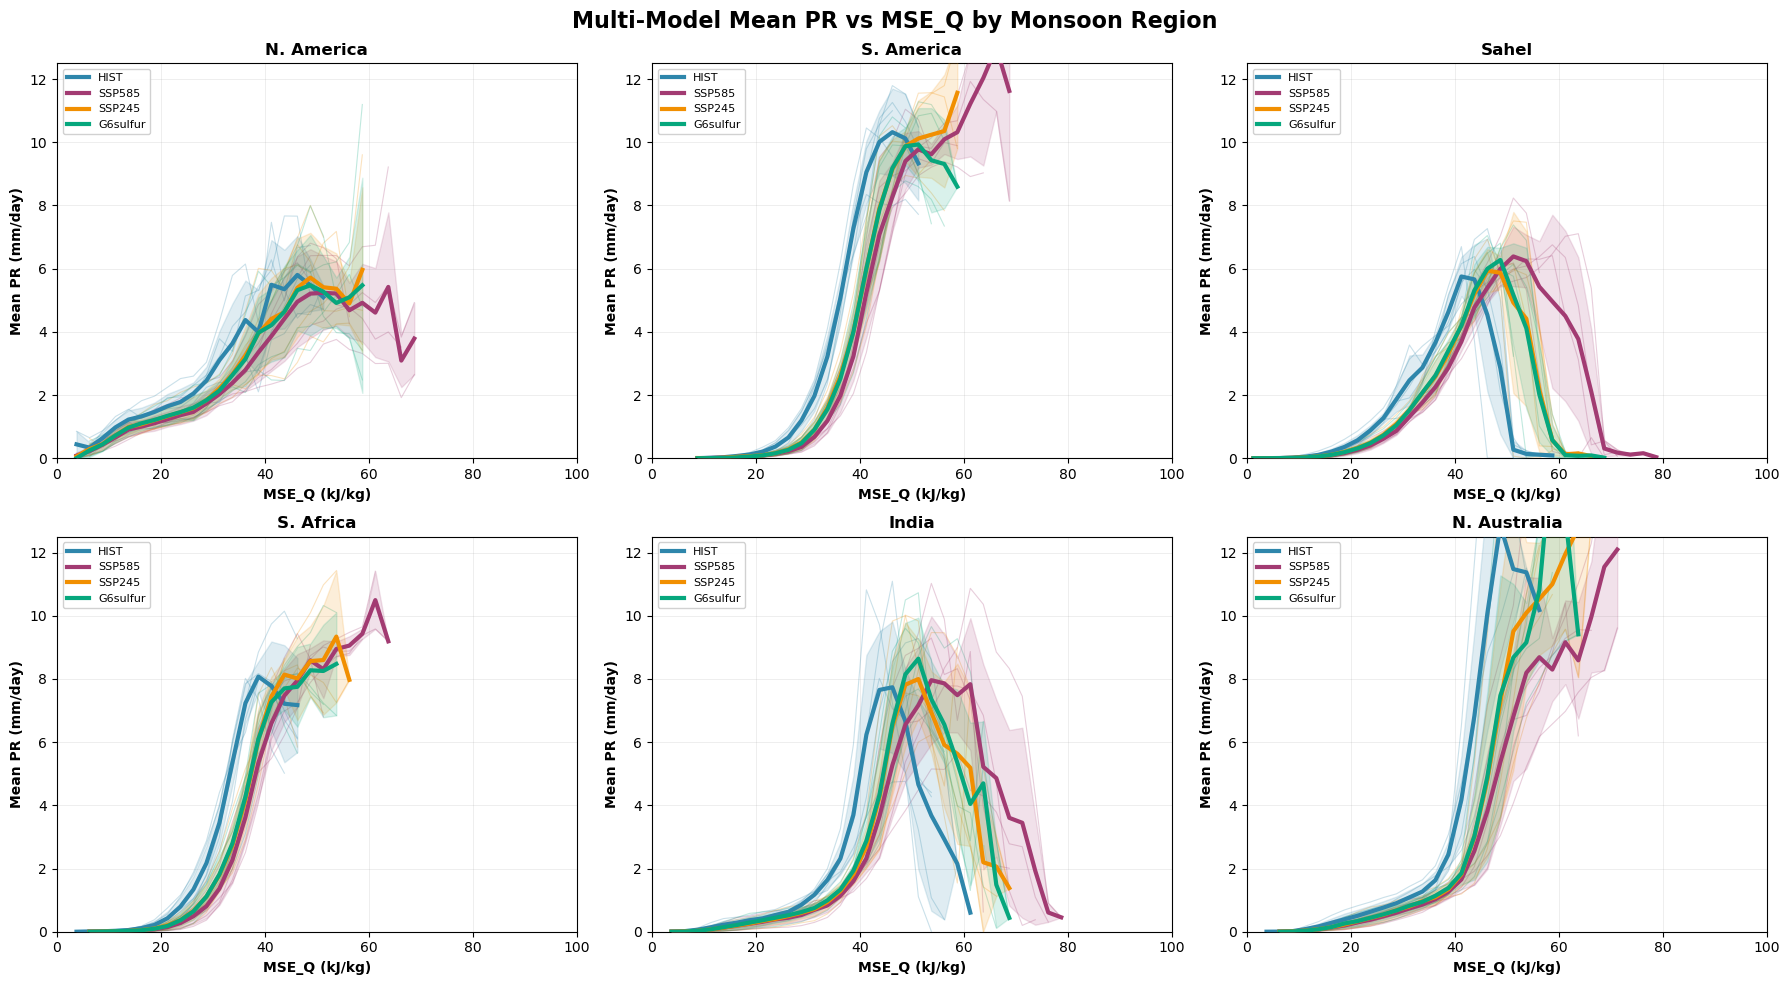

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os
import warnings
warnings.filterwarnings("ignore")
import xesmf as xe
from scipy import stats

# Add analysis path
analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)
import myfunctions as mf

# =========================
# Physical constants
# =========================
Cp = 1005.0    # J kg-1 K-1
Lv = 2.5e6     # J kg-1

# =========================
# Base CEDA paths
# =========================
CEDA_BASE = Path("/badc/cmip6/data/CMIP6")

# =========================
# Model Names
# =========================
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}

# =========================
# Experiment registry
# =========================
EXPERIMENTS_ORDER = ["HIST", "SSP585", "SSP245", "G6sulfur"]

EXPERIMENTS = {
    "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# =========================
# Monsoon regions (Bombardi & Boos 2021)
# =========================
regions = {
    'N. America':   {'lon': (248, 258), 'lat': (18,    33)},
    'S. America':   {'lon': (300, 318), 'lat': (-18.5, -7)},
    'Sahel':        {'lon': (0,   40),  'lat': (7,   18.5)},
    'S. Africa':    {'lon': (19.5, 31), 'lat': (-18.5, -7)},
    'India':        {'lon': (73,  87),  'lat': (15,    27)},
    'N. Australia': {'lon': (120.5, 149),'lat': (-21, -9.5)},
}

# =========================
# Utility functions
# =========================
def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return ("2021-01-01", "2100-12")
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")

def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    ds_in = da.to_dataset(name='data')
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da)

def select_region(da, lon_range, lat_range):
    """Select a region handling longitude wrapping properly."""
    lon_min, lon_max = lon_range
    lat_min, lat_max = lat_range
    
    # Ensure longitude is in 0-360 range
    if 'lon' in da.coords:
        lon_coords = da.lon.values
        if np.any(lon_coords < 0):
            da = da.assign_coords(lon=(da.lon % 360))
    
    # Select latitude
    da_regional = da.sel(lat=slice(lat_min, lat_max))
    
    # Select longitude (handles wrapping)
    if lon_min < lon_max:
        # Simple case: no wrapping
        da_regional = da_regional.sel(lon=slice(lon_min, lon_max))
    else:
        # Wrapping case (crosses dateline) - not applicable for our regions
        da_regional = da_regional.where(
            (da_regional.lon >= lon_min) | (da_regional.lon <= lon_max),
            drop=True
        )
    
    return da_regional

# =========================
# BLOCK 1: LOAD DATA AND COMPUTE REGIONAL SCATTER DATA
# =========================
print("="*80)
print("BLOCK 1: Loading data and computing MSE-PR arrays for monsoon regions")
print("="*80)

scatter_data_regional = {reg: {} for reg in regions.keys()}

for model_name, model_meta in MODELS.items():
    print(f"\n{'='*60}")
    print(f"Processing model: {model_name}")
    print(f"{'='*60}")
    
    for region_name, region_bounds in regions.items():
        scatter_data_regional[region_name][model_name] = {}

    for exp in EXPERIMENTS_ORDER:
        meta = EXPERIMENTS[exp]
        print(f"\n--- Experiment: {exp} ---")
        
        # Special-case ensemble override for CESM2-WACCM
        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        def make_base(vname):
            return (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / vname
                / model_meta["grid"]
                / "latest"
            )

        base_tas = make_base("tas")
        base_huss = make_base("huss")
        base_pr = make_base("pr")

        try:
            # Load datasets
            if model_name == "CESM2-WACCM":
                if meta["scenario"] == "G6sulfur":
                    ds_tas = mf.open_files_CESM_G6sulfur(base_tas)
                    ds_huss = mf.open_files_CESM_G6sulfur(base_huss)
                    ds_pr = mf.open_files_CESM_G6sulfur(base_pr)
                elif meta["scenario"] == "ssp585":
                    ds_tas = mf.open_files_CESM_ssp585(base_tas)
                    ds_huss = mf.open_files_CESM_ssp585(base_huss)
                    ds_pr = mf.open_files_CESM_ssp585(base_pr)
                else:
                    ds_tas = mf.open_files(str(base_tas))
                    ds_huss = mf.open_files(str(base_huss))
                    ds_pr = mf.open_files(str(base_pr))
            elif model_name == "IPSL-CM6A-LR":
                if meta["scenario"] == "ssp585":
                    ds_tas = mf.open_files_IPSL_ssp585(base_tas)
                    ds_huss = mf.open_files_IPSL_ssp585(base_huss)
                    ds_pr = mf.open_files_IPSL_ssp585(base_pr)
                else:
                    ds_tas = mf.open_files(str(base_tas))
                    ds_huss = mf.open_files(str(base_huss))
                    ds_pr = mf.open_files(str(base_pr))
            else:
                ds_tas = mf.open_files(str(base_tas))
                ds_huss = mf.open_files(str(base_huss))
                ds_pr = mf.open_files(str(base_pr))

            # Read variables
            da_tas = mf.read_var(ds_tas, "tas")
            da_huss = mf.read_var(ds_huss, "huss")
            da_pr = mf.read_var(ds_pr, "pr")
            
            # Drop unnecessary coordinates
            da_huss = da_huss.drop_vars(["plev", "height"], errors="ignore")
            da_tas = da_tas.drop_vars(["plev", "height"], errors="ignore")
            da_pr = da_pr.drop_vars(["plev", "height"], errors="ignore")

            # Time slice
            t_start, t_end = _time_slice(exp)
            da_tas_sliced = da_tas.sel(time=slice(t_start, t_end))
            da_huss_sliced = da_huss.sel(time=slice(t_start, t_end))
            da_pr_sliced = da_pr.sel(time=slice(t_start, t_end))

            # Compute MSEsfc in kJ/kg
            # da_mse = (Cp * da_tas_sliced + Lv * da_huss_sliced) / 1000.0
            da_mse = (Lv * da_huss_sliced) / 1000.0

            # Convert pr to mm/day
            da_pr_mmday = da_pr_sliced * 86400

            # Regrid to common grid
            print("  Regridding...")
            da_mse_regrid = regrid_to_common(da_mse)
            da_pr_regrid = regrid_to_common(da_pr_mmday)
            
            # Process each region
            for region_name, region_bounds in regions.items():
                # Select region
                da_mse_region = select_region(da_mse_regrid, 
                                              region_bounds['lon'], 
                                              region_bounds['lat'])
                da_pr_region = select_region(da_pr_regrid,
                                             region_bounds['lon'],
                                             region_bounds['lat'])
                
                # Flatten and remove NaNs
                mse_flat = da_mse_region.values.flatten()
                pr_flat = da_pr_region.values.flatten()
                
                valid_mask = ~(np.isnan(mse_flat) | np.isnan(pr_flat))
                mse_valid = mse_flat[valid_mask]
                pr_valid = pr_flat[valid_mask]
                
                # Store
                scatter_data_regional[region_name][model_name][exp] = {
                    'mse': mse_valid,
                    'pr': pr_valid
                }
                
                print(f"    {region_name}: {len(mse_valid):,} points")
            
        except Exception as e:
            print(f"  ✗ Error loading {exp}: {e}")
            for region_name in regions.keys():
                scatter_data_regional[region_name][model_name][exp] = None

print("\n" + "="*80)
print("BLOCK 1 COMPLETE")
print("="*80)

# =========================
# BLOCK 2: COMPUTE BINNED STATISTICS FOR EACH REGION
# =========================
print("\n" + "="*80)
print("BLOCK 2: Computing binned statistics for each region")
print("="*80)

# Define MSE bins
# mse_bins = np.arange(300, 381, 2.5)  # Focus on tropical MSE range
mse_bins = np.arange(0, 100, 2.5)  # Focus on tropical MSE range
mse_centers = (mse_bins[:-1] + mse_bins[1:]) / 2

binned_stats_regional = {reg: {} for reg in regions.keys()}

for region_name in regions.keys():
    print(f"\n--- Region: {region_name} ---")
    binned_stats_regional[region_name] = {}
    
    for model_name in MODELS.keys():
        binned_stats_regional[region_name][model_name] = {}
        
        for exp in EXPERIMENTS_ORDER:
            data = scatter_data_regional[region_name][model_name].get(exp)
            
            if data is not None:
                mse = data['mse']
                pr = data['pr']
                
                # Compute mean PR in each MSE bin
                pr_binned_mean = []
                pr_binned_std = []
                counts = []
                
                for i in range(len(mse_bins) - 1):
                    mask = (mse >= mse_bins[i]) & (mse < mse_bins[i+1])
                    pr_in_bin = pr[mask]
                    
                    if len(pr_in_bin) > 0:
                        pr_binned_mean.append(np.mean(pr_in_bin))
                        pr_binned_std.append(np.std(pr_in_bin))
                        counts.append(len(pr_in_bin))
                    else:
                        pr_binned_mean.append(np.nan)
                        pr_binned_std.append(np.nan)
                        counts.append(0)
                
                binned_stats_regional[region_name][model_name][exp] = {
                    'mse_centers': mse_centers,
                    'pr_mean': np.array(pr_binned_mean),
                    'pr_std': np.array(pr_binned_std),
                    'counts': np.array(counts)
                }

print("\n" + "="*80)
print("BLOCK 2 COMPLETE")
print("="*80)

# =========================
# BLOCK 3: PLOT MULTI-MODEL MEAN FOR EACH REGION
# =========================
print("\n" + "="*80)
print("BLOCK 3: Creating regional plots")
print("="*80)

# Define colors for experiments
exp_colors = {
    "HIST": "#2E86AB",      # Blue
    "SSP585": "#A23B72",    # Purple-red
    "SSP245": "#F18F01",    # Orange
    "G6sulfur": "#06A77D"   # Green
}

# Create figure with one panel per region
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle('Multi-Model Mean PR vs MSE_Q by Monsoon Region', 
             fontsize=16, fontweight='bold')

for reg_idx, region_name in enumerate(regions.keys()):
    ax = axes[reg_idx]
    
    for exp in EXPERIMENTS_ORDER:
        # Collect all models for this experiment in this region
        all_pr_binned = []
        
        # Plot individual models as thin lines
        for model_name in MODELS.keys():
            stats = binned_stats_regional[region_name][model_name].get(exp)
            
            if stats is not None:
                ax.plot(stats['mse_centers'], stats['pr_mean'],
                       color=exp_colors[exp], linewidth=0.8, 
                       alpha=0.25, linestyle='-')
                
                all_pr_binned.append(stats['pr_mean'])
        
        # Compute and plot multi-model mean
        if all_pr_binned:
            all_pr_binned = np.array(all_pr_binned)
            multimodel_mean = np.nanmean(all_pr_binned, axis=0)
            multimodel_std = np.nanstd(all_pr_binned, axis=0)
            
            # Plot multi-model mean as thick line
            ax.plot(mse_centers, multimodel_mean, 
                   color=exp_colors[exp], linewidth=3.0, 
                   label=f'{exp}', alpha=1.0, zorder=10)
            
            # Add shaded region for multi-model spread
            ax.fill_between(mse_centers, 
                           multimodel_mean - multimodel_std,
                           multimodel_mean + multimodel_std,
                           color=exp_colors[exp], alpha=0.15, zorder=5)
    
    # Formatting
    # ax.set_xlim(300, 380)    
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 12.5)
    ax.set_xlabel('MSE_Q (kJ/kg)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Mean PR (mm/day)', fontsize=10, fontweight='bold')
    ax.set_title(region_name, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9)

plt.tight_layout()

# # Save
# output_path = '/home/claude/mse_pr_monsoon_regions.png'
# plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
# print(f"✓ Figure saved: {output_path}")

# # Copy to outputs
# import shutil
# output_final = '/mnt/user-data/outputs/mse_pr_monsoon_regions.png'
# shutil.copy(output_path, output_final)
# print(f"✓ Figure copied to outputs")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)